In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("drawndata1.csv")

In [5]:
df.head()

,x,y,z
0,58.080365,225.699042,a
1,238.867357,247.456645,a
2,156.218212,286.588782,a
3,262.004361,284.251445,a
4,185.243183,308.187571,a


In [6]:
X = df[['x','y']].values

In [8]:
y = df['z'] == 'a'

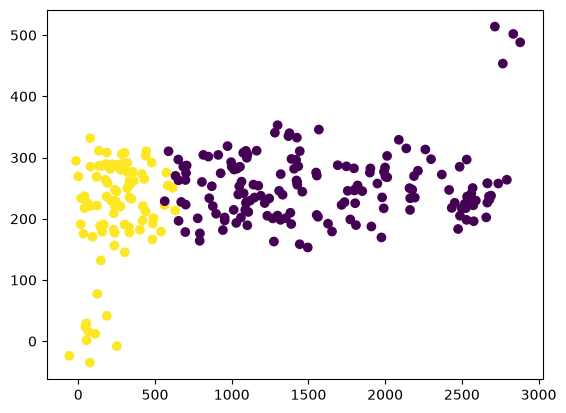

In [16]:
plt.scatter(X[:,0],X[:,1],c=y)

In [21]:
from sklearn.preprocessing import StandardScaler

In [25]:
X[:3,:]

array([[ 58.08036546, 225.69904242],
       [238.86735657, 247.45664533],
       [156.21821195, 286.58878233]])

In [26]:
X_new = StandardScaler().fit_transform(X)

In [27]:
X_new[:3,:]

array([[-1.28490284, -0.20293861],
       [-1.07019011,  0.10628636],
       [-1.16834885,  0.66244292]])

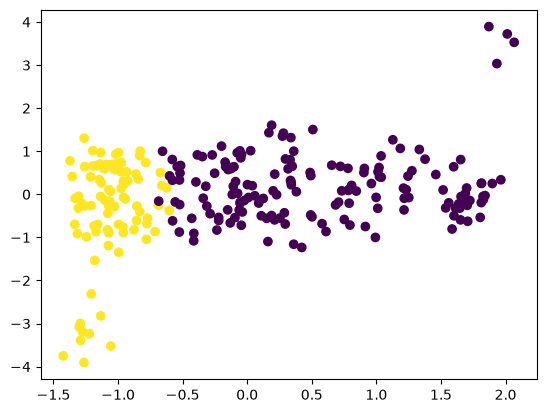

In [29]:
plt.scatter(X_new[:,0],X_new[:,1],c=y)

## using quantile transformer


In [30]:
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [31]:
df =  pd.read_csv('drawndata1.csv')

In [32]:
X = df[['x','y']].values

In [33]:
y =  df['z'] == "a" 

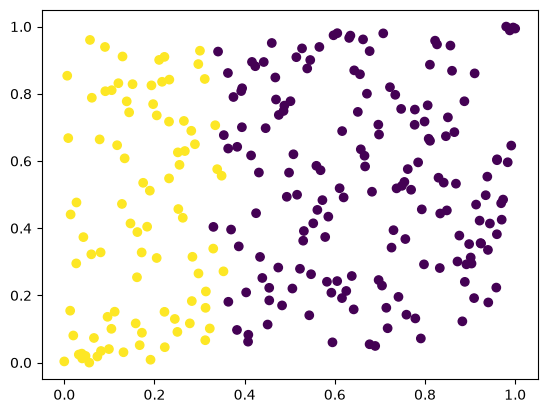

In [34]:
X_new = QuantileTransformer(n_quantiles=100).fit_transform(X)
plt.scatter(X_new[:,0],X_new[:,1],c=y)

In [ ]:
import pandas as pd
import numpy as np

In [36]:
df = pd.read_csv("drawndata2.csv")
df.head()

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a


In [37]:
X = df[['x','y']].values

In [38]:
y = df['z'] == 'a'

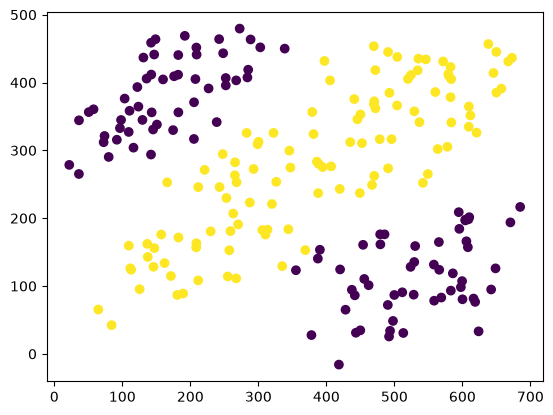

In [39]:
import matplotlib.pyplot as plt
plt.scatter(X[:,0],X[:,1], c=y)

## with liniar model (not good)

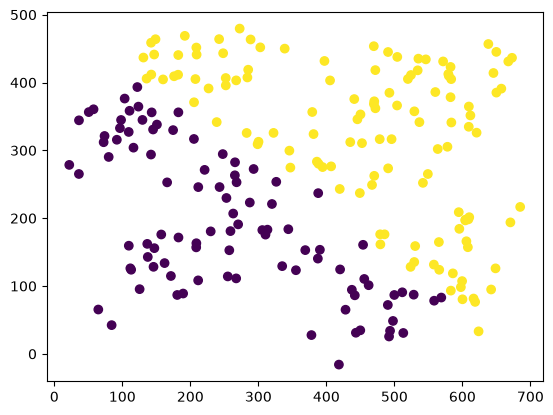

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
import matplotlib.pyplot as plt

pipe = Pipeline(
    [
        ('scale', QuantileTransformer(n_quantiles=100)),
        ('model', LogisticRegression())
    ]
)

pred = pipe.fit(X,y).predict(X)
plt.scatter(X[:,0],X[:,1], c=pred)

only seperate two classes.

## do preprocessing to use linear model

### use linear features to come up with none linear features

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [45]:
df = pd.read_csv("drawndata2.csv")
df.head()

,x,y,z
0,469.759355,453.574946,a
1,535.331819,435.221848,a
2,504.285526,437.767578,a
3,469.891398,368.371652,a
4,405.425622,403.141546,a


In [46]:
X = df[['x','y']].values

In [47]:
y = df['z'] == 'a'

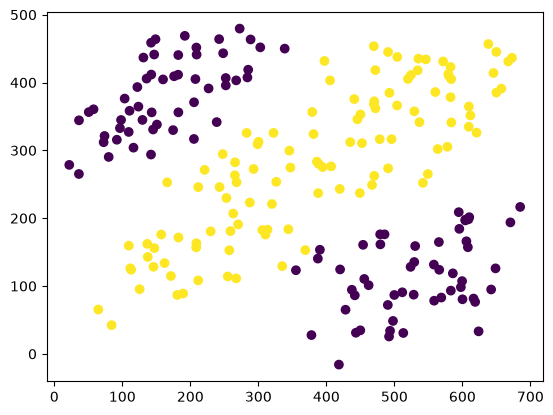

In [48]:
pipe = Pipeline(
    [
        ('scale', PolynomialFeatures()),
        ('model', LogisticRegression())
    ]
)

pred = pipe.fit(X,y).predict(X)
plt.scatter(X[:,0], X[:,1], c=pred)

### convert text data to numeric data

In [49]:
arr = np.array(["low","low","high","medium"]).reshape(-1,1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [53]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False)
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

if this enc got an unseen lable it now show an error like this

```python
ValueError: Found unknown categories ['zero'] in column 0 during transform
```

In [55]:
# enc.transform([["zero"]])

to solve this use one hot encoder like this

In [56]:
arr = np.array(["low","low","high","medium"]).reshape(-1,1)
arr

array([['low'],
       ['low'],
       ['high'],
       ['medium']], dtype='<U6')

In [57]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
enc.fit_transform(arr)

array([[0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.]])

In [58]:
enc.transform([['zero']])

array([[0., 0., 0.]])